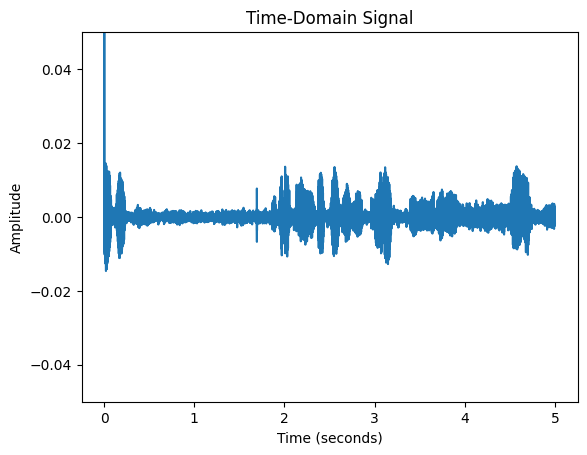

In [ ]:
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt

#Load audio file
audioSignal, samplingRate = sf.read('audio/capture.wav')
audioSignal = audioSignal - np.mean(audioSignal)
samplesAmount = len(audioSignal)
timeAxis = np.arange(samplesAmount) / samplingRate

#Plot the signal
plt.plot(timeAxis, audioSignal)
plt.ylim(-0.05, 0.05)
plt.title("Time-Domain Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


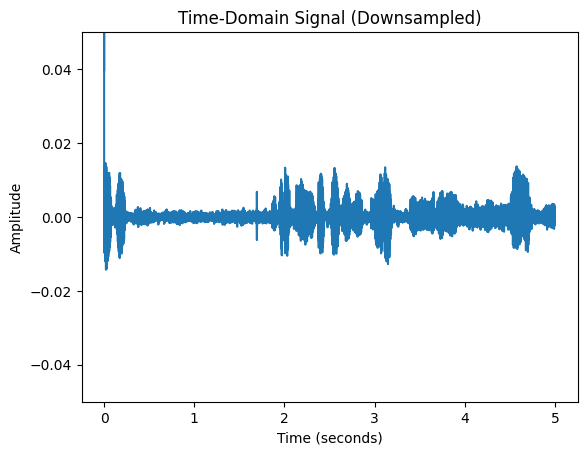

In [ ]:
#Downsample the audio to reduce computation
downsampleFactor = 3
downsampledSignal = audioSignal[::downsampleFactor]
downsampledSamplingRate = samplingRate / downsampleFactor

downsampledSamplesAmount = len(downsampledSignal)
downsampledTimeAxis = np.arange(downsampledSamplesAmount) / downsampledSamplingRate

#Plot the signal
plt.plot(downsampledTimeAxis, downsampledSignal)
plt.ylim(-0.05, 0.05) #Zoom in to the signal due to a spike at t=0
plt.title("Time-Domain Signal (Downsampled)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


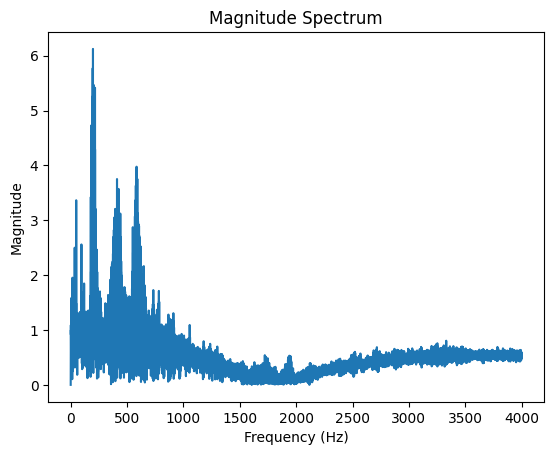

In [ ]:
signalLength = downsampledSamplesAmount
fftResult = np.fft.fft(downsampledSignal)
fftMagnitude = np.abs(fftResult)
fftFrequencyAxis = np.arange(signalLength) * downsampledSamplingRate / signalLength

plt.plot(fftFrequencyAxis[:signalLength//2], fftMagnitude[:signalLength//2])
plt.title("Magnitude Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()


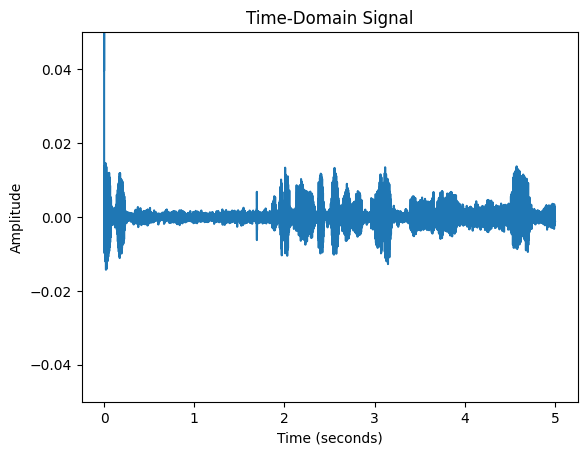

In [ ]:
#Fast inverse using NumPy for comparison
idftSignal = np.fft.ifft(fftResult).real

plt.plot(downsampledTimeAxis, idftSignal)
#plt.ylim(-0.05, 0.05)
plt.title("Time-Domain Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


In [ ]:
def FIRlow(W, N):
    n = np.arange(-N, N + 1)
    return W / np.pi * np.sinc(W / np.pi * n)

def FIRbandpass(Wlow, Whigh, N):
    return FIRlow(Whigh, N) - FIRlow(Wlow, N)

def f2W(f, fs):
    return 2 * np.pi * f / fs


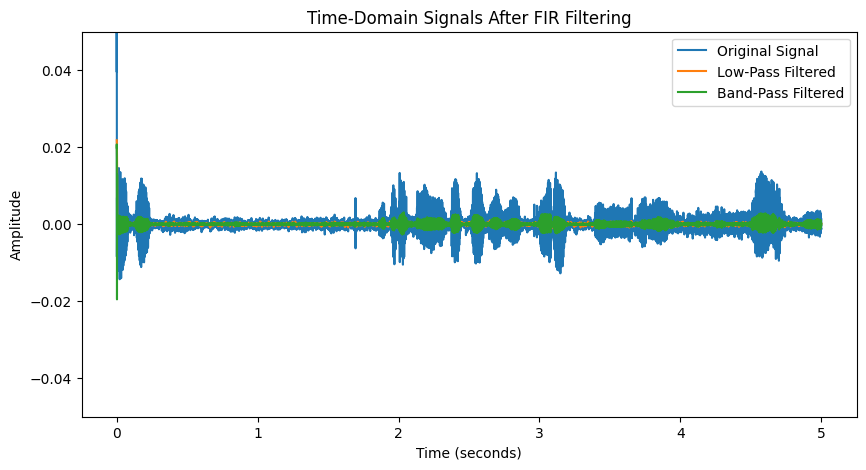

In [ ]:
filterLength = 21

#Filter values
lowPassCutoff = 300 #In Hertz
bandPassLow = 50 #In Hertz
bandPassHigh = 400 #In Hertz

lowPassKernel = FIRlow(f2W(lowPassCutoff, downsampledSamplingRate), filterLength)
bandPassKernel = FIRbandpass(f2W(bandPassLow, downsampledSamplingRate), f2W(bandPassHigh, downsampledSamplingRate), filterLength)

#Use convolution to apply the filters
filteredLowPass = np.convolve(downsampledSignal, lowPassKernel, mode='same')
filteredBandPass = np.convolve(downsampledSignal, bandPassKernel, mode='same')

#Filter plots comparison
plt.figure(figsize=(10,5))
plt.plot(downsampledTimeAxis, downsampledSignal, label="Original Signal")
plt.plot(downsampledTimeAxis, filteredLowPass, label="Low-Pass Filtered")
plt.plot(downsampledTimeAxis, filteredBandPass, label="Band-Pass Filtered")
plt.ylim(-0.05, 0.05)
plt.title("Time-Domain Signals After FIR Filtering")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

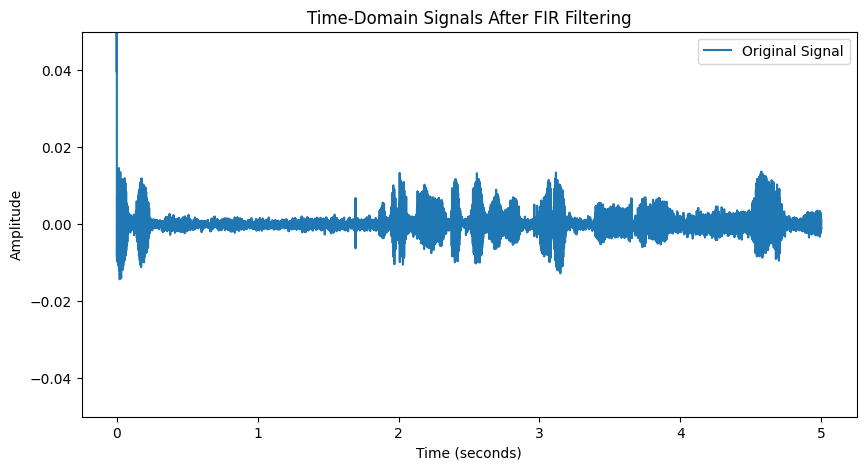

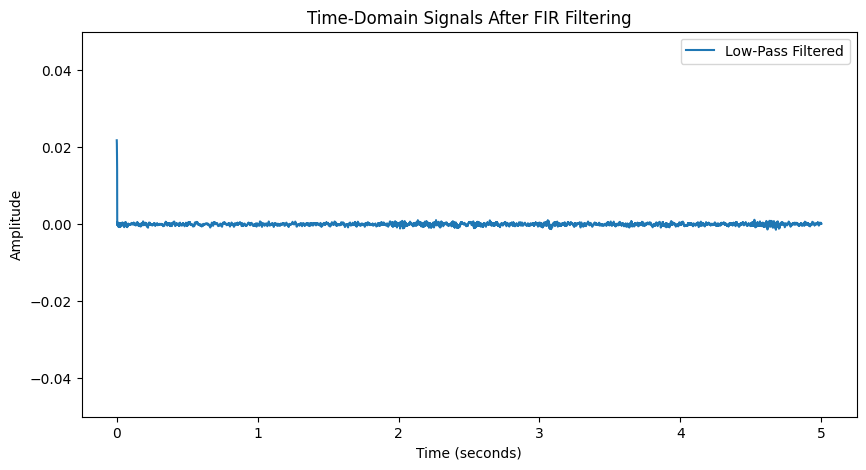

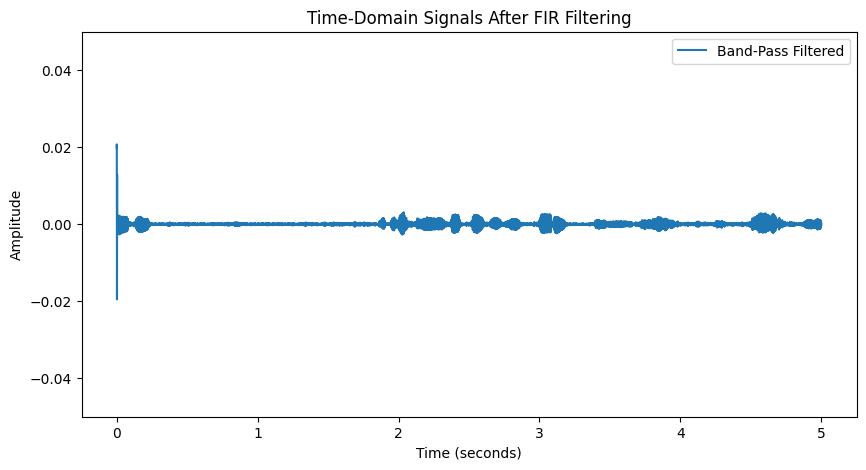

In [ ]:
#Show original signal plot
plt.figure(figsize=(10,5))
plt.plot(downsampledTimeAxis, downsampledSignal, label="Original Signal")
plt.ylim(-0.05, 0.05)
plt.title("Time-Domain Signals After FIR Filtering")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

#Show low-pass filter plot
plt.figure(figsize=(10,5))
plt.plot(downsampledTimeAxis, filteredLowPass, label="Low-Pass Filtered")
plt.ylim(-0.05, 0.05)
plt.title("Time-Domain Signals After FIR Filtering")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

#Show band-pass filter plot
plt.figure(figsize=(10,5))
plt.plot(downsampledTimeAxis, filteredBandPass, label="Band-Pass Filtered")
plt.ylim(-0.05, 0.05)
plt.title("Time-Domain Signals After FIR Filtering")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

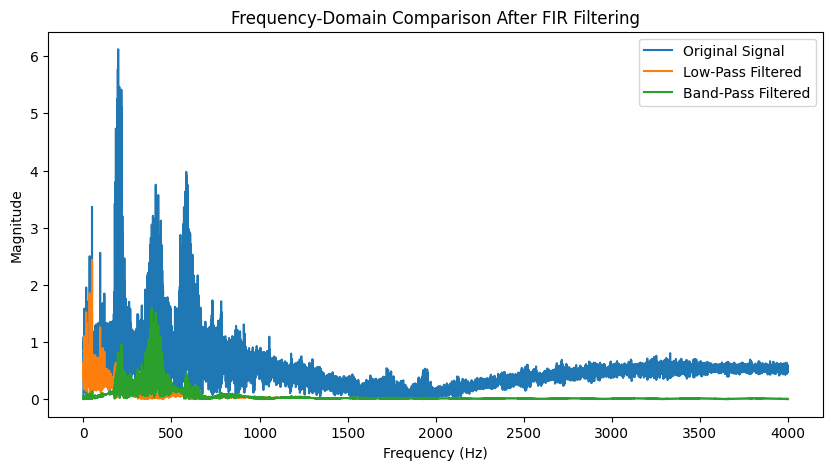

In [ ]:
#Compute FFT of signals for fast frequency-domain view
fftOriginal = np.fft.fft(downsampledSignal)
fftLowPass = np.fft.fft(filteredLowPass)
fftBandPass = np.fft.fft(filteredBandPass)

#Magnitude spectra
magnitudeOriginal = np.abs(fftOriginal)
magnitudeLowPass = np.abs(fftLowPass)
magnitudeBandPass = np.abs(fftBandPass)

#Frequency axis
frequencyAxis = np.arange(signalLength) * downsampledSamplingRate / signalLength

#Plot frequency comparison
plt.figure(figsize=(10,5))
plt.plot(frequencyAxis[:signalLength//2], magnitudeOriginal[:signalLength//2], label="Original Signal")
plt.plot(frequencyAxis[:signalLength//2], magnitudeLowPass[:signalLength//2], label="Low-Pass Filtered")
plt.plot(frequencyAxis[:signalLength//2], magnitudeBandPass[:signalLength//2], label="Band-Pass Filtered")
plt.title("Frequency-Domain Comparison After FIR Filtering")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.show()


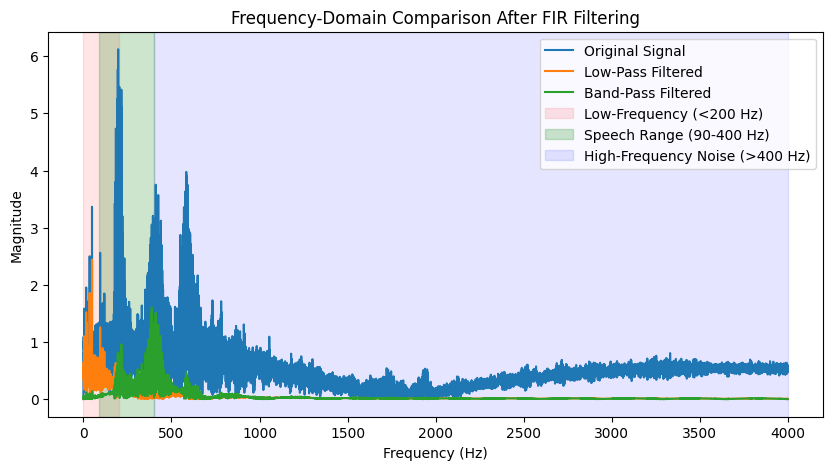

In [ ]:
#Compute FFT of signals for fast frequency-domain view
fftOriginal = np.fft.fft(downsampledSignal)
fftLowPass = np.fft.fft(filteredLowPass)
fftBandPass = np.fft.fft(filteredBandPass)

#Magnitude spectra
magnitudeOriginal = np.abs(fftOriginal)
magnitudeLowPass = np.abs(fftLowPass)
magnitudeBandPass = np.abs(fftBandPass)

#Frequency axis
frequencyAxis = np.arange(signalLength) * downsampledSamplingRate / signalLength

#Plot frequency comparison
plt.figure(figsize=(10,5))
plt.plot(frequencyAxis[:signalLength//2], magnitudeOriginal[:signalLength//2], label="Original Signal")
plt.plot(frequencyAxis[:signalLength//2], magnitudeLowPass[:signalLength//2], label="Low-Pass Filtered")
plt.plot(frequencyAxis[:signalLength//2], magnitudeBandPass[:signalLength//2], label="Band-Pass Filtered")

#Highlight frequency ranges
plt.axvspan(0, 200, color='red', alpha=0.1, label="Low-Frequency (<200 Hz)")
plt.axvspan(90, 400, color='green', alpha=0.2, label="Speech Range (90-400 Hz)")
plt.axvspan(400, 4000, color='blue', alpha=0.1, label="High-Frequency Noise (>400 Hz)")

plt.title("Frequency-Domain Comparison After FIR Filtering")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.show()
